ILI SEIR

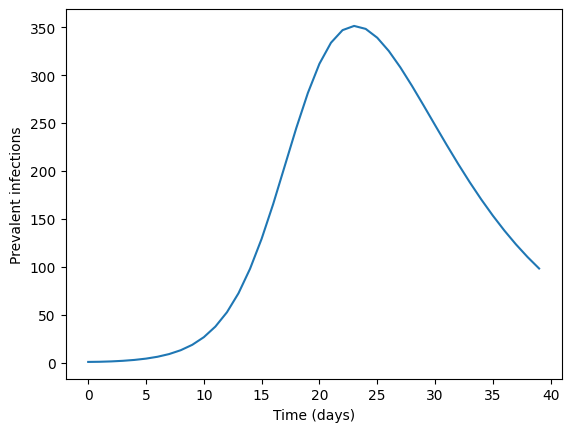

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

ili_data = pd.read_csv("./data/ili_data.csv")
hhs1_data = ili_data.loc[ ili_data.region == "hhs1" ].reset_index()
hhs1_data = hhs1_data.loc[:,['epiweek','ili']]
hhs1_s1 = hhs1_data.iloc[39:80]
hhs1_s1 = hhs1_s1.reset_index(drop=True)
hhs1_s1['time'] = np.arange(len(hhs1_s1))

n = 1000 
def seir(t,y, beta, sigma, gamma,n):
    s,e,i,r, c = y
    ds_dt = -beta*s*i/n
    de_dt = beta*s*i/n - sigma*e
    di_dt =  sigma*e - gamma*i
    dr_dt = gamma*i
    
    dc_dt = beta*s*i/n            
    return [ds_dt,de_dt, di_dt, dr_dt, dc_dt]


start,end = 0., 40


tvals = np.arange(start,end)


initial_conditions = (998,1 ,1, 0, 0)


beta, sigma, gamma = 3./2, 1/5.2 ,1./7


solution = solve_ivp( fun = seir
                     , t_span = (start,end)
                     , y0     = initial_conditions
                     , t_eval = tvals
                     , args   = (beta,sigma,gamma,n))
prevalent_infections = solution.y[2,:]
times                = solution.t 

plt.plot(times,prevalent_infections)
plt.xlabel("Time (days)")
plt.ylabel("Prevalent infections")
plt.show()


data = pd.DataFrame({"times":hhs1_s1['time'], "infections":hhs1_s1['ili']})

from scipy.optimize import minimize 
def SSE(params,data,n):                         #--lets assume n is fixed 
    beta,sigma,gamma = params                         #--"Unroll" parameters from the variable params
    #--Build our SIR model of the expected y
    
    #--SIR differential equations
    def seir(t,y, beta, sigma, gamma,n):
        s,e,i,r, c = y
        ds_dt = -beta*s*i/n
        de_dt = beta*s*i/n - sigma*e
        di_dt =  sigma*e - gamma*i
        dr_dt = gamma*i
    
        dc_dt = beta*s*i/n            
        return [ds_dt,de_dt, di_dt, dr_dt, dc_dt]
        
    #--inital conditions for s, i, r      Assume fixed for now
    initial_conditions = (998, 1,1, 0., 0)

    start = min(data.times)
    end   = max(data.times) 
    
    solution = solve_ivp( fun = seir
                     , t_span = (start,end)
                     , y0     = initial_conditions
                     , t_eval = data.times.values  #<--evaluate our solution at all the x values we have in the data
                     , args   = (beta,sigma,gamma,n))
    prevalent_infections = solution.y[2,:]
    times                = solution.t 

    return np.mean( (prevalent_infections - data.infections.values)**2 ) #--Compute the SSE

results = minimize( lambda x: SSE(x,data=data,n=1000), x0=np.array([3,0.2,0.1])  )
print(results)


beta,sigma,gamma = results.x

initial_conditions = (998,1,1, 0., 0)

start = min(data.times)
end   = max(data.times) 

solution = solve_ivp( fun = seir
                 , t_span = (start,end)
                 , y0     = initial_conditions
                 , t_eval = data.times.values  #<--evaluate our solution at all the x values we have in the data
                 , args   = (beta, sigma, gamma,n))
prevalent_infections = solution.y[2,:]
times                = solution.t 

plt.scatter(data.times.values,data.infections.values,s=5)
plt.plot(times,prevalent_infections)
plt.legend()
plt.show()
